In [1]:
%load_ext autoreload
%autoreload 2

import os
import jax
import matplotlib.pyplot as plt

os.chdir("..")
import numpy as np
from flax import serialization

from src.c3po.analysis.analysis import C3poAnalysis
from src.c3po.model.model import C3PO

# analysis=C3poAnalysis(None, None, None)

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


# Loading

## Load in data objects

In [14]:
import numpy as np
from scipy.io import loadmat

data_name = "/stelmo/sam/c3po_results/moserdata.mat"
# data_name = "/stelmo/sam/c3po_datasets/moser_mec_25843_2_openfield.mat"


data = loadmat(
    data_name
    # "/stelmo/sam/c3po_datasets/moser_mec_25843_2_openfield.mat"
)  # in the downloadable Vollan archive, this is 27765_2.mat  (potentially can do this with any other data file)


def mat_fields(s):
    """Return field names for a MATLAB struct (np.void or structured ndarray)."""
    if isinstance(s, np.ndarray) and s.dtype.names:
        return s.dtype.names
    if isinstance(s, np.void) and s.dtype.names:
        return s.dtype.names
    raise TypeError("Not a MATLAB struct (np.void/structured ndarray).")


# The 'Dsession' key gives the main struct
Dsession = data["Dsession"]

t = Dsession["t"][0, 0].flatten()  # times
x = Dsession["x"][0, 0].flatten()  # x positions
y = Dsession["y"][0, 0].flatten()  # y positions
speed = Dsession["speed"][0, 0].flatten()  #
thetaphase = Dsession["theta"][0, 0].flatten()  #
units = Dsession["units"][0, 0].flatten()  # unit data (more parsing below)
unit_cluster_id = units["mec"][0]["acorrCluId"][:]

head_dir = Dsession["hd"][0, 0].flatten()
hd_cont = np.unwrap(head_dir)
ang_vel = np.gradient(hd_cont, np.median(np.diff(t)))
ind_jump = np.where(np.diff(t) > 0.1)[0]
ang_vel[ind_jump] = 0
ang_vel[ind_jump + 1] = 0

moser_hd_decode = Dsession["lmt"][0][0][0][0][0]["id"][0][0]["XA"][0][0].flatten()
moser_hd_error = np.angle(np.exp(1j * (moser_hd_decode - head_dir)))
moser_hd_decode.shape, t.shape

((130000,), (130000,))

In [3]:
t_spikes = np.arange(t[0], t[-1], 0.002)
spikes = []
for uu in range(len(units["mec"][0]["spikeTimes"])):
    spikes.append(units["mec"][0]["spikeTimes"][uu][0].flatten())

len(spikes)


from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

smoothing_window = 0.02  # in seconds
smoothing_window = 0.003  # in seconds
dt = t_spikes[1] - t_spikes[0]
smoothing_window_bins = int(smoothing_window / dt)
rates = []

for uu in tqdm(range(len(spikes))):
    rate, _ = np.histogram(
        spikes[uu], bins=np.concatenate([t_spikes, [t_spikes[-1] + (dt)]])
    )
    # rate = np.convolve(
    #     rate,
    #     np.ones(smoothing_window_bins) / smoothing_window_bins,
    #     mode="same",
    # )
    rate = gaussian_filter1d(
        rate[:, None].astype("float"),
        sigma=smoothing_window_bins,
        axis=0,
        mode="nearest",
    )

    rates.append(rate / (t[1] - t[0]))  # in Hz
rates = np.squeeze(rates).T

100%|██████████| 460/460 [00:22<00:00, 20.43it/s]


In [4]:
# plt.hist(np.log10(np.diff(t)))
# plt.yscale("log")
# np.median(np.diff(t))
dt = np.diff(t)

ind_valid = (dt < 0.02).astype(int)  # only use intervals with dt < 20 ms
starts = np.where(np.diff(ind_valid) == 1)[0] + 1
ends = np.where(np.diff(ind_valid) == -1)[0] + 1
if ind_valid[0]:
    starts = np.insert(starts, 0, 0)
if ind_valid[-1]:
    ends = np.append(ends, len(ind_valid))
valid_intervals = [[t[s], t[e]] for s, e in zip(starts, ends)]

## Load in encoding results

In [5]:
from src.c3po.tables.dev_tables import C3POStorage
import matplotlib.pyplot as plt

C3POStorage()  # .alter()
model_name = "mec_wavenet_25843_all_cells"
model_name = "mec_wavenet_all_cells"


# model_name = "moser_mec_29502_1_openfield_wavenet_all_cells"
# model_name = f"mec_{data_name.split('/')[-1].split('.')[0]}_jan2026"

# key = {"model_name": "mec_wavenet_all_cells"}
key = dict(model_name=model_name)

analysis = (C3POStorage & key).fetch_analysis_object()

analysis.load_embedding(f"/stelmo/sam/c3po_results/{key['model_name']}_embedding.npz")

diff_t = np.diff(analysis.t)
bad_diff = np.where(diff_t > 0.1)[0] + 1
bad_diff = np.concatenate([[0], bad_diff, np.array([len(analysis.t)])])
no_gap_intervals = []
for i in range(len(bad_diff) - 1):
    no_gap_intervals.append((analysis.t[bad_diff[i]], analysis.t[bad_diff[i + 1] - 1]))
no_gap_intervals = np.array(no_gap_intervals)[:-7]

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.fit_context_pca(fit_intervals=no_gap_intervals)

# Just showing how to access the variables
# t = analysis.t
z = analysis.z
c = analysis.c
c_pca = analysis.c_pca
t_interp = analysis.t_interp
c_interp = analysis.c_interp
c_pca_interp = analysis.c_pca_interp

entry = (C3POStorage & key).fetch1()
latent_dim = entry["latent_dim"]
context_dim = entry["context_dim"]

# define figure directory
from src.c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "Fig3" / "mec_open_field" / model_name
os.makedirs(figure_folder, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"  # to get editable text in Illustrator

[2026-06-10 13:53:42,083][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [112]:
hd_gain = np.sum(analysis.c_pca[:,[1,2]]**2,axis=1)**.5
gain_color = "forestgreen"

# Analysis

In [6]:
import matplotlib.pyplot as plt
from spyglass.common.common_interval import Interval

# Head Direction Decoding

## Perform 5-fold cross validated decodings

In [ ]:
t_feature = t
feature = head_dir[:, None]

decoder_version = []

decoder_version.append(
    dict(
    model_type="discretized_regression",
    n_bins=100,
    max_iter=1000,
    balance_groups=True,
    multidim=False,
    predict_method="weighted_angle",
))
decoder_version.append(
    dict(
    model_type="circular_knn",
    n_neighbors=30,
    weights="uniform",
    # weights="distance",
    # metric="cosine",
))

decoder_results = {}
for version in decoder_version:
    analysis.initialize_decoder(**version)
    t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
        feature,
        t_feature,
        intervals=valid_intervals,
        # pca=True,
        # decode_dim=slice(1, 2),
        interpolate=True,
        # smooth_context=1,
    )
    t_pred = np.concatenate(t_pred_list)
    feature_pred = np.concatenate(feature_pred_list)

    hd_t_pred = t_pred
    hd_pred = feature_pred[:, 0]
    ind_map = np.digitize(t_pred, t_feature)
    error = np.angle(np.exp(1j * (feature_pred - feature[ind_map])))
    hd_error = np.angle(np.exp(1j * (hd_pred - feature[ind_map, 0])))

    results = dict(
        t_pred=t_pred,
        hd_pred=hd_pred,
        hd_error=hd_error,
    )
    decoder_results[version["model_type"]] = results

Cross-validating decoder:   0%|          | 0/5 [00:00<?, ?it/s]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(100372, 1) (100372, 16)
-3.141565 3.141478


Cross-validating decoder:  20%|██        | 1/5 [00:28<01:52, 28.02s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(107448, 1) (107448, 16)
-3.141565 3.141478


Cross-validating decoder:  40%|████      | 2/5 [00:59<01:29, 29.86s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

Cross-validating decoder:  60%|██████    | 3/5 [01:27<00:58, 29.17s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141565 3.141478
(105752, 1) (105752, 16)
-3.141565 3.141478


Cross-validating decoder:  80%|████████  | 4/5 [01:53<00:27, 27.97s/it]/home/sambray/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


-3.141539 3.141478
(109149, 1) (109149, 16)
-3.141539 3.141478


Cross-validating decoder: 100%|██████████| 5/5 [00:24<00:00,  4.96s/it]


In [24]:
decoder_results["moser"] = dict(
    t_pred=t,
    hd_pred=moser_hd_decode,
    hd_error=moser_hd_error,
)

## Compare decoder errors vs phase

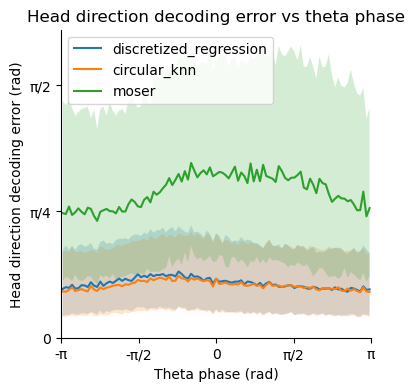

In [ ]:
theta_bins = np.linspace(-np.pi, np.pi, 100)
from c3po.analysis.analysis import interval_list_contains_ind
fig = plt.figure(figsize=(4, 4))
for decoder,results  in decoder_results.items():
    ind_valid = interval_list_contains_ind(no_gap_intervals, results["t_pred"])

    ind_theta = np.digitize(results["t_pred"][ind_valid], t)
    error_theta = thetaphase[ind_theta]
    mid = []
    low = []
    high = []
    error = np.abs(results["hd_error"][ind_valid])
    for i in range(1, len(theta_bins)):
        ind_bin = (error_theta >= theta_bins[i - 1]) & (error_theta < theta_bins[i])
        mid.append(np.median(error[ind_bin]))
        low.append(np.percentile(error[ind_bin], 25))
        high.append(np.percentile(error[ind_bin], 75))
    plt.fill_between(
        (theta_bins[:-1] + theta_bins[1:]) / 2,
        low,
        high,
        alpha=0.2,
        zorder = -3
    )
    plt.plot((theta_bins[:-1] + theta_bins[1:]) / 2, mid, label=decoder)
plt.legend()

plt.xlabel("Theta phase (rad)")
plt.ylabel("Head direction decoding error (rad)")
plt.title("Head direction decoding error vs theta phase")
plt.xlim(-np.pi, np.pi)
plt.xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi], ["-π", "-π/2", "0", "π/2", "π"])
# plt.ylim(0, np.pi/2)
plt.yticks([0, np.pi / 4, np.pi / 2], ["0", "π/4", "π/2"])

ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)

fig.savefig(figure_folder / "hd_error_vs_theta_phase.svg")

Text(0.5, 0, 'Time (s)')

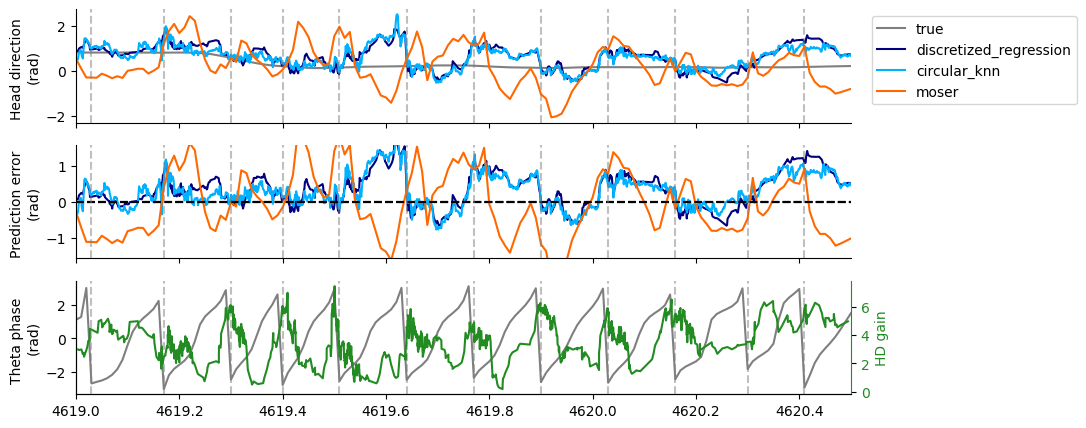

In [ ]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 5))

t_rng = 5000.5, 5002
t_rng = 4619, 4620.5

pred_ax = ax[0]
err_ax = ax[1]
theta_ax = ax[2]

colors = plt.cm.jet([0,.3,.8])
feature_ind = np.logical_and(t_feature >= t_rng[0], t_feature <= t_rng[1])
xx = t_feature[feature_ind]
yy = feature[feature_ind]
pred_ax.plot(xx, yy, c="k", alpha=0.5, label="true")
for i, (decoder, results) in enumerate(decoder_results.items()):
    t_pred = results["t_pred"]
    feature_pred = results["hd_pred"]
    error = results["hd_error"]
    ind_pred = np.logical_and(t_pred >= t_rng[0], t_pred <= t_rng[1])
    pred_ax.plot(t_pred[ind_pred], feature_pred[ind_pred], c=colors[i], label=decoder)



    # ind_map = np.digitize(t_pred, t_feature)
    # error = feature_pred - feature[ind_map]
    err_ax.plot(t_pred[ind_pred], error[ind_pred], c=colors[i], label=decoder)
    err_ax.axhline(0, c="k", ls="--")
    err_ax.set_ylim(-np.pi / 2, np.pi / 2)

pred_ax.legend(bbox_to_anchor=(1.30, 1), loc="upper right")

ind_gain =np.logical_and(analysis.t >= t_rng[0], analysis.t <= t_rng[1])
gain_ax = theta_ax.twinx()
gain_ax.plot(analysis.t[ind_gain], hd_gain[ind_gain], c=gain_color, label="HD gain")
gain_ax.set_ylabel("HD gain", color=gain_color)
gain_ax.tick_params(axis='y', labelcolor=gain_color)
gain_ax.spines['right'].set_color(gain_color)
gain_ax.spines['top'].set_visible(False)

# err_ax.legend()

theta_ax.plot(t_feature[feature_ind], thetaphase[feature_ind], c="k", alpha=0.5)


delta_theta = np.diff(thetaphase[feature_ind], prepend=0)
ind_mark = np.where(np.abs(delta_theta) > np.pi)[0]
for im in ind_mark:
    for a in ax:
        a.axvline(t_feature[feature_ind][im], c="gray", ls="--", alpha=0.5)

for a in ax:
    a.spines[["right", "top"]].set_visible(False)

plt.xlim(*t_rng)

pred_ax.set_ylabel("Head direction \n(rad)")
err_ax.set_ylabel("Prediction error \n(rad)")
theta_ax.set_ylabel("Theta phase \n(rad)")
plt.xlabel("Time (s)")

# fig.savefig(figure_folder / "head_direction_decoding_example.svg")

## Error power spectrums

In [119]:
window_size = 4  # seconds
window_error = int(window_size / np.mean(np.diff(t_pred)))
window_feature = int(window_size / np.mean(np.diff(t_feature)))
nfft = 100



# fft_results = {}
# for decoder, results in tqdm(decoder_results.items()):
#         source_y = results["hd_error"]
#         t_source = results["t_pred"]
#         # plt.hist(np.diff(t_source), bins=100)
#         t_source_interp = np.arange(t_source[0], t_source[-1], 0.001)
#         source_y_interp = np.interp(t_source_interp, t_source, source_y)
#         window_size = 4  # seconds
#         window_error = int(window_size / np.mean(np.diff(t_source_interp)))
#         window_feature = int(window_size / np.mean(np.diff(t_source_interp)))
#         nfft = 100
#         f, mid, lo, hi = analysis.power_spectrum(
#             intervals=no_gap_intervals,
#             window_size=window_error,
#             nfft=nfft * window_error,
#             sourced_data=(t_source_interp, source_y_interp[:,None]),
#         )
#         fft_results[decoder] = dict(f=f, mid=mid, lo=lo, hi=hi)


source_y = head_dir[:,None]
source_y = np.exp(1j * source_y)
f_feature, mid_feature, lo_feature, hi_feature = analysis.power_spectrum(
    intervals=valid_intervals,
    window_size=window_feature,
    nfft=nfft * window_feature,
    sourced_data=(t, source_y),
)

source_y = hd_gain
t_source = analysis.t
# plt.hist(np.diff(t_source), bins=100)
t_source_interp = np.arange(t_source[0], t_source[-1], 0.001)
source_y_interp = np.interp(t_source_interp, t_source, source_y)

window_error = int(window_size / np.mean(np.diff(t_source_interp)))
window_feature = int(window_size / np.mean(np.diff(t_source_interp)))
nfft = 100
f_gain, mid_gain, lo_gain, hi_gain = analysis.power_spectrum(
    intervals=no_gap_intervals,
    window_size=window_error,
    nfft=nfft * window_error,
    sourced_data=(t_source_interp, source_y_interp[:,None]),
)

/home/sambray/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


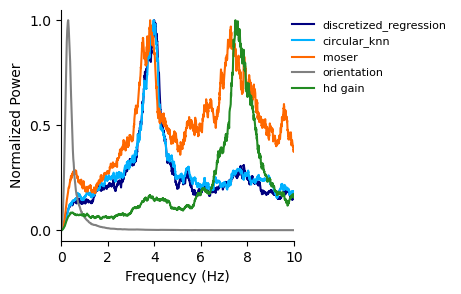

In [121]:
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111)

for i,(decoder, results) in enumerate(decoder_results.items()):
    f = fft_results[decoder]["f"]
    mid = fft_results[decoder]["mid"]
    plot_mid = mid[0]
    plot_f = f.copy()
    plot_mid = plot_mid * plot_f
    scale = np.max(plot_mid)
    plot_mid = plot_mid /scale
    ind = plot_f >= 0
    plot_mid = plot_mid[ind]
    plot_f = plot_f[ind]
    plot_lo = fft_results[decoder]["lo"][0][ind]*plot_f /scale
    plot_hi = fft_results[decoder]["hi"][0][ind]*plot_f / scale
    plt.plot(plot_f, plot_mid, label=decoder, color=colors[i])
    # plt.fill_between(plot_f, plot_lo, plot_hi, color=colors[i], alpha=0.2)

# plot_mid = mid_decode[0]
# plot_f = f_decode.copy()
# plot_mid = plot_mid * plot_f
# plot_mid = plot_mid / np.max(plot_mid)
# plt.plot(plot_f, plot_mid, label="decode orientation")

plot_mid = mid_feature[0]
plot_f = f_feature.copy()
plot_mid = plot_mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
ind = plot_f >= 0
plot_mid = plot_mid[ind]
plot_f = plot_f[ind]
plt.plot(plot_f, plot_mid, label="orientation", color="grey")

plot_mid = mid_gain[0]
plot_f = f_gain .copy()
plot_mid = plot_mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
ind = plot_f >= 0
plot_mid = plot_mid[ind]
plot_f = plot_f[ind]
plt.plot(plot_f, plot_mid, label="hd gain", color=gain_color)

# plt.xscale('log')

plt.xlim(0, 10)
# plt.xticks([0,10,20])
plt.yticks([0, 0.5, 1])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.legend(fontsize=8, frameon=False, loc="upper right",bbox_to_anchor=(1.70, 1),)
ax.spines[["right", "top"]].set_visible(False)

# fig.savefig(figure_folder / "head_direction_decoding_error_spectrum.svg")

3.14158867016604
3.1414526
3.1415448


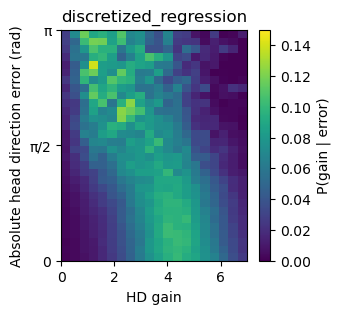

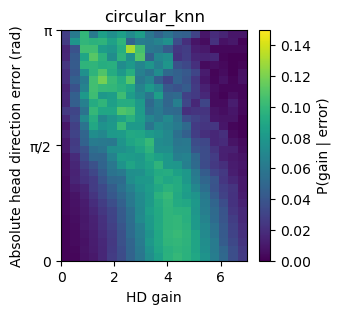

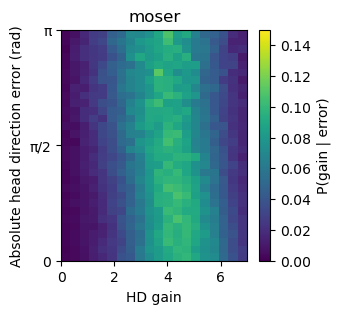

In [ ]:
bx = np.linspace(0, 7, 21)
by = np.linspace(0, np.pi, 31)

for i,(model_type, results) in enumerate(decoder_results.items()):
    fig = plt.figure(figsize=(3, 3))
    t_error = results["t_pred"]
    error = results["hd_error"]
    ind_valid = interval_list_contains_ind(no_gap_intervals[7:], t_error)#[::30]
    error_valid = np.abs(error[ind_valid])
    print(np.max(error_valid))
    # error_valid = np.log10(error_valid)
    t_error_valid = t_error[ind_valid]

    ind_gain = np.digitize(t_error_valid, analysis.t)
    gain_valid = hd_gain[ind_gain]
    color = colors[i]
    H,bx,by = np.histogram2d(gain_valid, error_valid, bins=[bx,by], density=False)

    H = H.T
    H = H/np.sum(H,axis=1, keepdims=True)

    plt.imshow(H, origin="lower", aspect="auto", extent=[bx[0], bx[-1], by[0], by[-1]])
    plt.clim(0,.15)
    plt.colorbar(label="P(gain | error)")
    plt.title(model_type)
    plt.xlabel("HD gain")
    plt.ylabel("Absolute head direction error (rad)")
    plt.yticks([0, np.pi/2, np.pi], ["0", "π/2", "π"])

In [157]:
np.sum(H,axis=1,).shape

(30,)

## Abs error power spectrums

In [105]:
window_size = 4  # seconds
window_error = int(window_size / np.mean(np.diff(t_pred)))
window_feature = int(window_size / np.mean(np.diff(t_feature)))
nfft = 100



fft_results = {}
for decoder, results in tqdm(decoder_results.items()):
        source_y = results["hd_error"]
        source_y = np.abs(source_y)
        t_source = results["t_pred"]
        # plt.hist(np.diff(t_source), bins=100)
        t_source_interp = np.arange(t_source[0], t_source[-1], 0.001)
        source_y_interp = np.interp(t_source_interp, t_source, source_y)
        window_size = 4  # seconds
        window_error = int(window_size / np.mean(np.diff(t_source_interp)))
        window_feature = int(window_size / np.mean(np.diff(t_source_interp)))
        nfft = 100
        f, mid, lo, hi = analysis.power_spectrum(
            intervals=no_gap_intervals,
            window_size=window_error,
            nfft=nfft * window_error,
            sourced_data=(t_source_interp, source_y_interp[:,None]),
        )
        fft_results[decoder] = dict(f=f, mid=mid, lo=lo, hi=hi)


source_y = feature
source_y = np.exp(1j * source_y)
f_feature, mid_feature, lo_feature, hi_feature = analysis.power_spectrum(
    intervals=valid_intervals,
    window_size=window_feature,
    nfft=nfft * window_feature,
    sourced_data=(t_feature, source_y),
)

source_y = hd_gain
t_source = analysis.t
# plt.hist(np.diff(t_source), bins=100)
t_source_interp = np.arange(t_source[0], t_source[-1], 0.001)
source_y_interp = np.interp(t_source_interp, t_source, source_y)
window_error = int(window_size / np.mean(np.diff(t_source_interp)))
window_feature = int(window_size / np.mean(np.diff(t_source_interp)))
nfft = 100
f_gain, mid_gain, lo_gain, hi_gain = analysis.power_spectrum(
    intervals=no_gap_intervals,
    window_size=window_error,
    nfft=nfft * window_error,
    sourced_data=(t_source_interp, source_y_interp[:,None]),
)

100%|██████████| 3/3 [00:23<00:00,  7.82s/it]


ValueError: array of sample points is empty

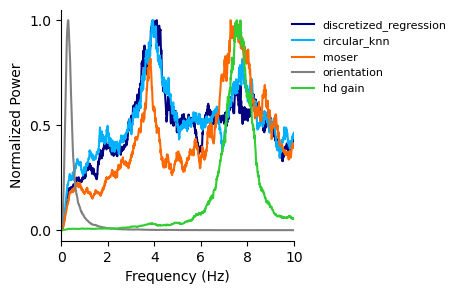

In [106]:
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111)

for i,(decoder, results) in enumerate(decoder_results.items()):
    f = fft_results[decoder]["f"]
    mid = fft_results[decoder]["mid"]
    plot_mid = mid[0]
    plot_f = f.copy()
    plot_mid = plot_mid * plot_f
    scale = np.max(plot_mid)
    plot_mid = plot_mid /scale
    ind = plot_f >= 0
    plot_mid = plot_mid[ind]
    plot_f = plot_f[ind]
    plot_lo = fft_results[decoder]["lo"][0][ind]*plot_f /scale
    plot_hi = fft_results[decoder]["hi"][0][ind]*plot_f / scale
    plt.plot(plot_f, plot_mid, label=decoder, color=colors[i])
    # plt.fill_between(plot_f, plot_lo, plot_hi, color=colors[i], alpha=0.2)

# plot_mid = mid_decode[0]
# plot_f = f_decode.copy()
# plot_mid = plot_mid * plot_f
# plot_mid = plot_mid / np.max(plot_mid)
# plt.plot(plot_f, plot_mid, label="decode orientation")

plot_mid = mid_feature[0]
plot_f = f_feature.copy()
plot_mid = plot_mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
ind = plot_f >= 0
plot_mid = plot_mid[ind]
plot_f = plot_f[ind]
plt.plot(plot_f, plot_mid, label="orientation", color="grey")

plot_mid = mid_gain[0]
plot_f = f_gain .copy()
plot_mid = plot_mid * plot_f
plot_mid = plot_mid / np.max(plot_mid)
ind = plot_f >= 0
plot_mid = plot_mid[ind]
plot_f = plot_f[ind]
plt.plot(plot_f, plot_mid, label="hd gain", color="limegreen")

# plt.xscale('log')

plt.xlim(0, 10)
# plt.xticks([0,10,20])
plt.yticks([0, 0.5, 1])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.legend(fontsize=8, frameon=False, loc="upper right",bbox_to_anchor=(1.70, 1),)
ax.spines[["right", "top"]].set_visible(False)

# fig.savefig(figure_folder / "head_direction_decoding_error_spectrum.svg")

# Neuron Embedding_analysis

## Head directio: Neuron embedding

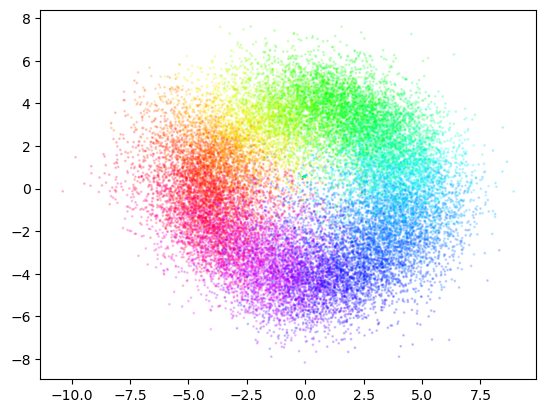

In [13]:
# context embedding
c_feature_dims = [1,2]

subset = slice(None, None, 50)
ind_dir = np.digitize(analysis.t, t_pred)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, c_feature_dims[0]],
    c_pca[subset][:, c_feature_dims[1]],
    s=1,
    alpha=0.2,
    c=hd_pred[ind_dir[subset] - 1],
    cmap="hsv",
    rasterized=True,
)

Text(0.5, 0, 'Time (s)')

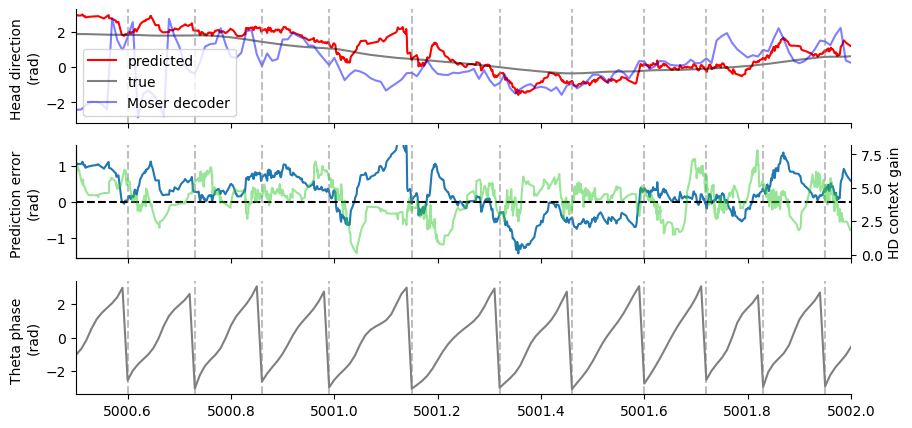

In [ ]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(10, 5))

t_rng = 5000.5, 5002

# t_rng = t_pred.min(), t_pred.min()+100

# t_rng = 4619, 4620.5

# t_rng = 4640, 4643.5
# t_rng = 4619, 4620.5

pred_ax = ax[0]
err_ax = ax[1]
theta_ax = ax[2]

ind_pred = np.logical_and(t_pred >= t_rng[0], t_pred <= t_rng[1])
pred_ax.plot(t_pred[ind_pred], feature_pred[ind_pred], c="r", label="predicted")
feature_ind = np.logical_and(t_feature >= t_rng[0], t_feature <= t_rng[1])
xx = t_feature[feature_ind]
yy = feature[feature_ind]
pred_ax.plot(xx, yy, c="k", alpha=0.5, label="true")
moser_ind = np.logical_and(t >= t_rng[0], t <= t_rng[1])
pred_ax.plot(
    t[moser_ind], moser_hd_decode[moser_ind], c="b", alpha=0.5, label="Moser decoder"
)

pred_ax.legend()


# ang_vel_ax = pred_ax.twinx()
# ang_vel_ax.set_ylabel("Angular velocity \n(rad/s)")
# ind_ang_vel = np.logical_and(t >= t_rng[0], t <= t_rng[1])
# # ang_vel_ax.plot(t[ind_ang_vel], np.abs(ang_vel[ind_ang_vel]), c="b", alpha=0.5)
# ang_vel_ax.plot(t[ind_ang_vel], (ang_vel[ind_ang_vel]), c="b", alpha=0.5)

# ind_map = np.digitize(t_pred, t_feature)
# error = feature_pred - feature[ind_map]
err_ax.plot(t_pred[ind_pred], error[ind_pred])
err_ax.axhline(0, c="k", ls="--")
err_ax.set_ylim(-np.pi / 2, np.pi / 2)

ind_gain = np.logical_and(analysis.t >= t_rng[0], analysis.t <= t_rng[1])
gain_plot = hd_gain[ind_gain]
# gain_plot = gain_plot - np.mean(gain_plot)
# gain_plot = gain_plot / np.max(gain_plot)
gain_ax = err_ax.twinx()
gain_ax.set_ylabel("HD context gain")
gain_ax.plot(analysis.t[ind_gain], gain_plot, c="limegreen", alpha=0.5)


theta_ax.plot(t_feature[feature_ind], thetaphase[feature_ind], c="k", alpha=0.5)


delta_theta = np.diff(thetaphase[feature_ind], prepend=0)
ind_mark = np.where(np.abs(delta_theta) > np.pi)[0]
for im in ind_mark:
    for a in ax:
        a.axvline(t_feature[feature_ind][im], c="gray", ls="--", alpha=0.5)


for a in ax:
    a.spines[["right", "top"]].set_visible(False)
gain_ax.spines["top"].set_visible(False)

plt.xlim(*t_rng)

pred_ax.set_ylabel("Head direction \n(rad)")
err_ax.set_ylabel("Prediction error \n(rad)")
theta_ax.set_ylabel("Theta phase \n(rad)")
plt.xlabel("Time (s)")

# fig.savefig(figure_folder / "head_direction_decoding_example.svg")

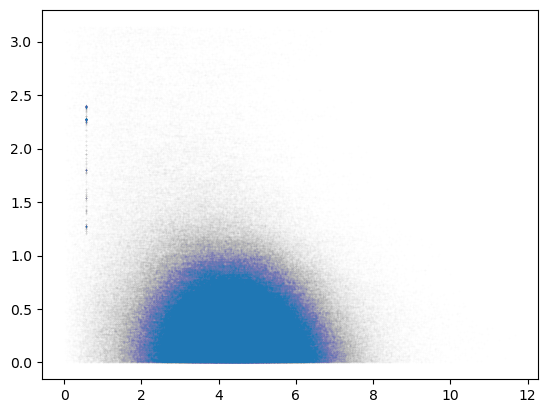

In [ ]:
# plt.scatter
# plt.scatter(hd_gain, np.abs(ang_vel[ind_match]), alpha=0.002, s=5)
from src.c3po.analysis.analysis import interval_list_contains_ind

ind = interval_list_contains_ind(
    no_gap_intervals,
    analysis.t,
)
ind_match = np.digitize(analysis.t[ind], t_pred) - 1
hd_gain.shape, hd_pred.shape
plt.scatter(hd_gain[ind], np.abs(hd_error[ind_match]), alpha=0.002, s=1)

In [73]:
analysis.bin_context_by_feature?

Signature:
analysis.bin_context_by_feature(
    feature: numpy.ndarray,
    feature_times: numpy.ndarray,
    bins=None,
    valid_intervals=None,
    pca=False,
    interpolated=False,
    alt_data=None,
    projection_name=None,
)
Docstring:
Bin the context by co-occurring feature values

Args:
    feature (np.ndarray): Feature values. Shape (n_samples,).
    feature_times (np.ndarray): Times of the feature values. Shape (n_samples,).
    bins (int, optional): Number of bins to use. Defaults to None.
    valid_intervals (np.ndarray, optional): Intervals to consider. Defaults to None.
    alt_data (np.ndarray, optional): Alternative data to bin instead of context. Defaults to None.
File:      ~/Documents/c3po/src/c3po/analysis/analysis.py
Type:      method

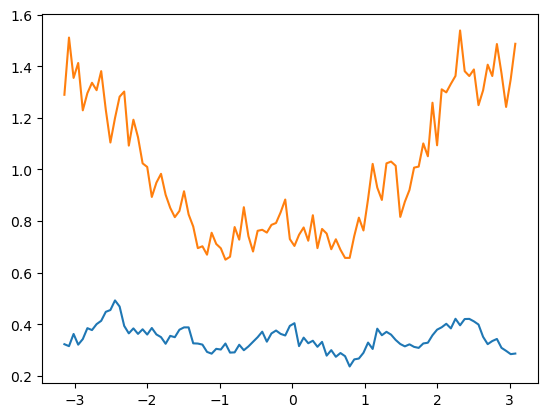

In [ ]:
results, bins = analysis.bin_context_by_feature(
    feature=head_dir,
    feature_times=t,
    valid_intervals=no_gap_intervals,
    alt_data=(t_pred, np.abs(hd_error)),
    bins=100,
)
mid = [np.median(r) for r in results]
lo = [np.percentile(r, 25) for r in results]
hi = [np.percentile(r, 75) for r in results]
plt.plot(bins[:-1], mid)

results, bins = analysis.bin_context_by_feature(
    feature=head_dir,
    feature_times=t,
    valid_intervals=no_gap_intervals,
    alt_data=(t, np.abs(moser_hd_error)),
    bins=100,
)
mid = [np.median(r) for r in results]
lo = [np.percentile(r, 25) for r in results]
hi = [np.percentile(r, 75) for r in results]
plt.plot(bins[:-1], mid)

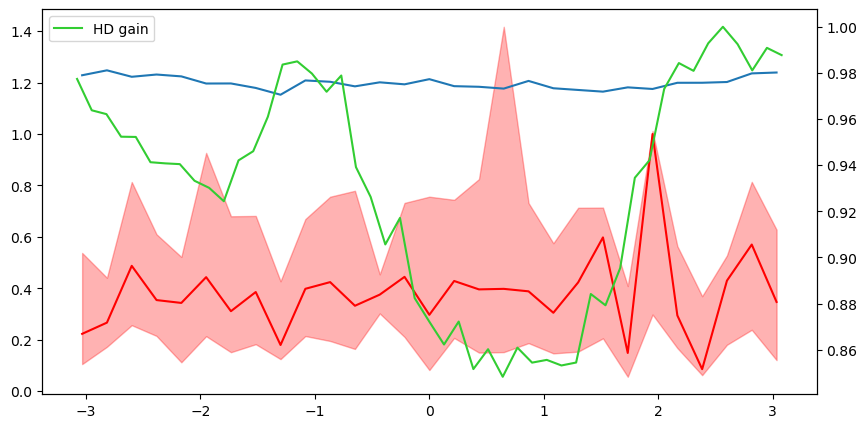

In [ ]:
gain_theta_ind = np.digitize(analysis.t, t)
gain_theta = thetaphase[gain_theta_ind - 1]
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

gain_ax = ax.twinx()
bins = np.linspace(-np.pi, np.pi, 50)
vals = []
for i in range(len(bins) - 1):
    ind = np.where((gain_theta >= bins[i]) & (gain_theta < bins[i + 1]))[0]
    vals.append(hd_gain[ind].mean())
gain_ax.plot(
    (bins[:-1] + bins[1:]) / 2, vals / np.max(vals), c="limegreen", label="HD gain"
)


error_theta_ind = np.digitize(t_pred, t)
error_theta = thetaphase[error_theta_ind - 1]
bins = np.linspace(-np.pi, np.pi, 30)
vals = []
lo = []
hi = []
for i in range(len(bins) - 1):
    ind = np.where((error_theta >= bins[i]) & (error_theta < bins[i + 1]))[0]
    xx = np.abs(hd_error[ind])
    # xx = error[ind]
    # xx = xx[xx < np.pi ]
    vals.append(np.median(xx))
    lo.append(np.percentile(xx, 25))
    hi.append(np.percentile(xx, 75))
ax.plot((bins[:-1] + bins[1:]) / 2, vals / np.max(vals), label="Decoding error", c="r")
ax.fill_between(
    (bins[:-1] + bins[1:]) / 2,
    np.array(lo) / np.max(vals),
    np.array(hi) / np.max(vals),
    color="r",
    alpha=0.3,
)


bins = np.linspace(-np.pi, np.pi, 30)
vals = []
for i in range(len(bins) - 1):
    ind = np.where((thetaphase >= bins[i]) & (thetaphase < bins[i + 1]))[0]
    xx = ang_vel[ind]
    xx = np.abs(xx)
    # xx =xx[xx<3]

    # xx = np.log(xx + 1e-8)
    # xx = xx[xx < np.pi / 2]
    vals.append(np.mean(xx))
ax.plot(
    (bins[:-1] + bins[1:]) / 2,
    vals,
    label="Angular velocity",
)
plt.legend()

## Theta phase embedding

In [71]:
W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]
W = W @ analysis.pca.components_.T


t_feature = t.copy()
feature = thetaphase.copy()
c_feature_dims = [0, 3]
# c_feature_dims = [4,5]
# t_feature = t.copy()
# feature = x


# t_feature = t.copy()
# feature = thetaphase
# c_feature_dims = [0,3]


t_spike_feature_ind = np.digitize(t_spikes, t_feature)
t_spike_feature = feature[t_spike_feature_ind - 1]

feature_bins = np.linspace(-np.pi, np.pi, 100)
feature_tuning_curves = []

for i in tqdm(range(feature_bins.size - 1)):
    bin_ind = np.where(
        (t_spike_feature >= feature_bins[i]) & (t_spike_feature < feature_bins[i + 1])
    )[0]
    # spike_counts = np.zeros(W.shape[0])
    # for bi in bin_ind:
    #     spike_counts += rates[bi]
    # feature_tuning_curves.append(spike_counts / len(bin_ind))
    spike_counts = rates[bin_ind].mean(axis=0)
    feature_tuning_curves.append(spike_counts)

feature_tuning_curves = np.array(feature_tuning_curves)

# c_feature_dims = [15,13]

W_feature = W[:, c_feature_dims]
W_angles = np.arctan2(W_feature[:, 0], W_feature[:, 1])
W_mag = np.linalg.norm(W_feature, 2, axis=1)
W_angles.shape

100%|██████████| 99/99 [00:02<00:00, 40.68it/s]


(460,)

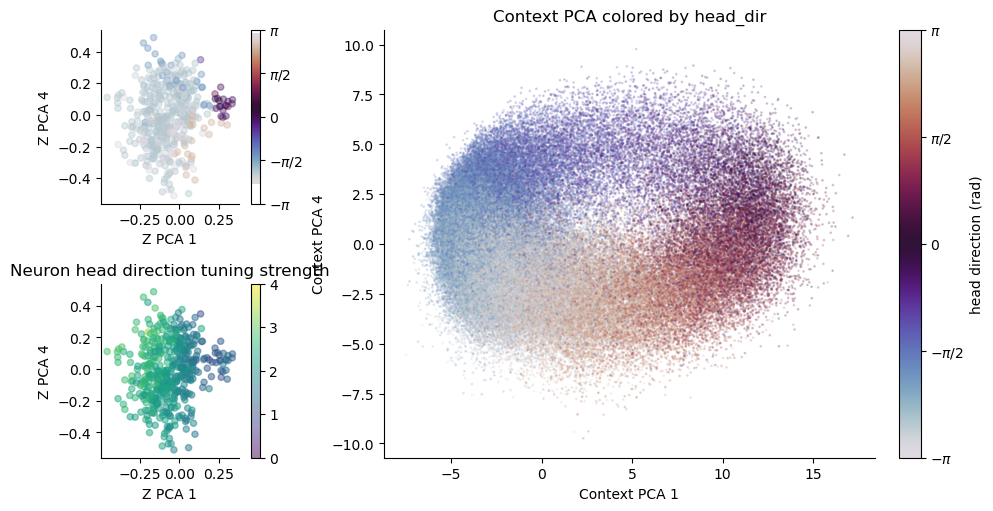

In [72]:
# fig, ax = plt.subplots(ncols=3, figsize=(10,3), sharex = True, sharey=True)
# fig = plt.figure(figsize=(8,4))
# ax = []
# ax.append(fig.add_subplot(2, 2, 1))
# ax.append(fig.add_subplot(2, 2, 3))
# ax.append(fig.add_subplot(1,2,2))

from matplotlib.gridspec import GridSpec
from src.c3po.toy_model_generators.phase import gaussian

fig = plt.figure(constrained_layout=True, figsize=(10, 5))
gs = GridSpec(2, 3, figure=fig)
tuning_ax = fig.add_subplot(gs[0, 0])
strength_ax = fig.add_subplot(gs[1, 0])
context_ax = fig.add_subplot(gs[:, 1:])

# Neuron tuning color
a = tuning_ax
color = np.argmax(feature_tuning_curves, axis=0)
color = feature_bins[:-1][color]
sc = a.scatter(
    W_feature[:, 0],
    W_feature[:, 1],
    c=color,
    edgecolor=None,
    cmap="twilight",
    alpha=0.4,
    s=20,
)
cbar = plt.colorbar(
    sc,
    ax=a,
)
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
# a.set_title("Neuron preferred head direction")

# Neuron tuning strength color
a = strength_ax
tuning_strength = np.max(feature_tuning_curves, axis=0) / np.median(
    feature_tuning_curves, axis=0
)
tuning_strength = np.log2(tuning_strength)
sc = a.scatter(
    W_feature[:, 0],
    W_feature[:, 1],
    c=tuning_strength,
    edgecolor=None,
    cmap="viridis",
    alpha=0.5,
    clim=(0, 4),
    s=20,
)
cbar = plt.colorbar(
    sc,
    ax=a,
)
# cbar.set_label('Tuning strength (spikes/s)')
a.set_title("Neuron head direction tuning strength")


# context embedding
subset = slice(None, None, 10)
ind_dir = np.digitize(analysis.t, t)
# ind_data = ind_data[subset]
sc = plt.scatter(
    c_pca[subset][:, c_feature_dims[0]],
    c_pca[subset][:, c_feature_dims[1]],
    s=1,
    alpha=0.2,
    c=feature[ind_dir[subset] - 1],
    cmap="twilight",
    rasterized=True,
)
cbar = plt.colorbar(label="head direction (rad)")
cbar.solids.set_alpha(1)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
plt.xlabel(f"Context PCA {c_feature_dims[0]+1}")
plt.ylabel(f"Context PCA {c_feature_dims[1]+1}")
plt.title("Context PCA colored by head_dir")

for a in [
    tuning_ax,
    strength_ax,
]:
    a.set_aspect("equal", "box")
    a.set_xlabel(f"Z PCA {c_feature_dims[0]+1}")
    a.set_ylabel(f"Z PCA {c_feature_dims[1]+1}")

for a in [tuning_ax, strength_ax, context_ax]:
    a.spines[["top", "right"]].set_visible(False)

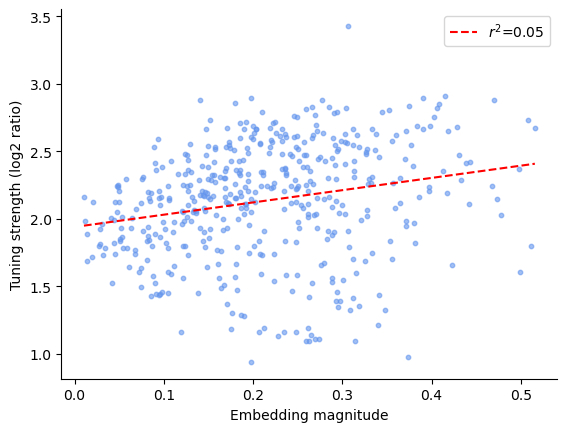

In [73]:
fig = plt.figure()

tuning_strength = np.max(feature_tuning_curves, axis=0) / np.median(
    feature_tuning_curves, axis=0
)
tuning_strength = np.log2(tuning_strength)

plt.scatter(W_mag, tuning_strength, color="cornflowerblue", alpha=0.6, s=10)

plt.xlabel("Embedding magnitude")
plt.ylabel("Tuning strength (log2 ratio)")

from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(W_mag, tuning_strength)
x_fit = np.array([W_mag.min(), W_mag.max()])
y_fit = intercept + slope * x_fit
plt.plot(x_fit, y_fit, c="r", ls="--", label=f"$r^2$={r_value**2:.2f}")
plt.legend()

ax = fig.gca()
ax.spines[["top", "right"]].set_visible(False)

Text(0.5, 1.0, 'Neuron head direction tuning curves')

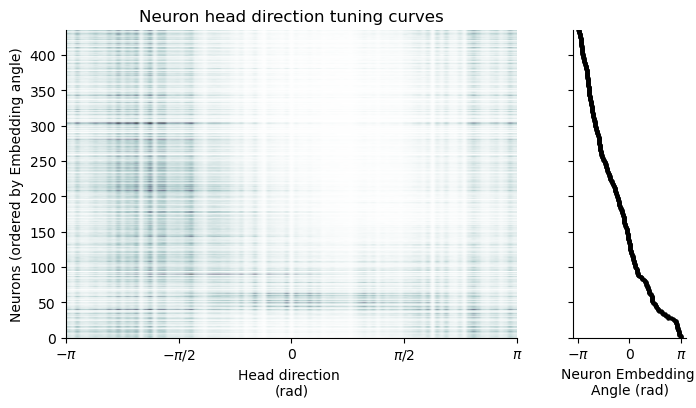

In [ ]:
fig, ax = plt.subplots(ncols=2, sharey=True, figsize=(8, 4), width_ratios=[4, 1])

ind_include = W_mag > 0.05
feature_tuning_curves.shape

# spike_order = np.argsort(np.argmax(feature_tuning_curves, axis=0))
spike_order = np.argsort(W_angles[ind_include])

plot_curves = feature_tuning_curves[:, ind_include][:, spike_order].T.copy()
# plot_curves = feature_tuning_curves[:, ind_include][:, spike_order].T.copy()
# plot_curves = plot_curves / np.mean(plot_curves, axis=1, keepdims=True)
ax[0].imshow(
    plot_curves,
    aspect="auto",
    extent=(feature_bins[0], feature_bins[-1], 0, plot_curves.shape[0]),
    cmap="bone_r",
)

ax[1].scatter(
    W_angles[ind_include][spike_order],
    np.sum(ind_include) - np.arange(np.sum(ind_include)),
    c="k",
    s=5,
)


ax[0].set_xlabel("Head direction \n(rad)")
ax[0].set_ylabel("Neurons (ordered by Embedding angle)")

ax[1].set_xlabel("Neuron Embedding \nAngle (rad)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
ax[0].set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

ax[1].set_xticks([-np.pi, 0, np.pi])
ax[1].set_xticklabels([r"$-\pi$", "0", r"$\pi$"])

ax[0].set_title("Neuron head direction tuning curves")

In [77]:
plot_curves.shape, feature_tuning_curves.shape, W_angles.shape

((436, 99), (99, 460), (460,))

## Firing rate: null model embedding

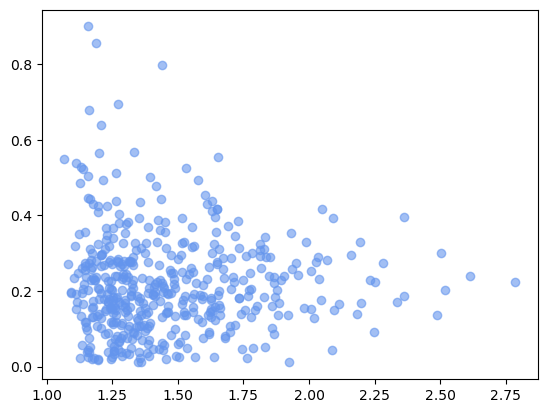

In [ ]:
from src.c3po.analysis.analysis import interval_list_contains_ind

W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]


# W_mag = np.linalg.norm(W, ord=2, axis=1)
W_mag = 1 * np.sum(W**2, axis=-1)
W_mag = np.exp(W_mag)

rates.shape, W_mag.shape
ind_rates = interval_list_contains_ind(
    valid_intervals,
    t_spikes,
)

mean_rate = rates.mean(axis=0)
# mean_rate = np.log(mean_rate)
# mean_rates = np.log(rates[ind_rates] + 1e-3).mean(axis=0)

plt.scatter(W_mag, mean_rate, color="cornflowerblue", alpha=0.6)

# Neuron  grid bases contribution

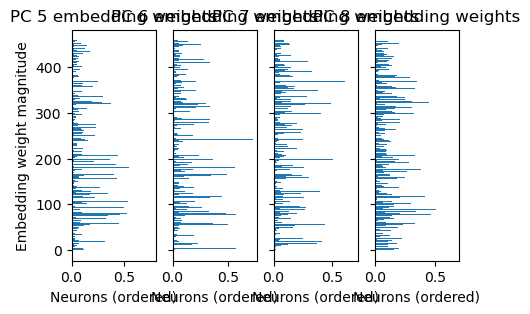

In [ ]:
dim = [4, 5, 6, 7]

W = analysis.params["params"]["embedding"]["encoder"]["encoder_matrix"]
W = W @ analysis.pca.components_.T

W = np.abs(W)

fig, ax = plt.subplots(ncols=len(dim), sharey=True, figsize=(5, 3))

ind = np.argsort(W[:, 1])

for i, d in enumerate(dim):
    ax[i].barh(np.arange(W.shape[0]), W[ind, d])
    ax[i].set_title(f"PC {d+1} embedding weights")
    ax[i].set_xlabel("Neurons (ordered)")
    if i == 0:
        ax[i].set_ylabel("Embedding weight magnitude")

# plt.scatter(W[:,6],W[:,5])

# W_mag = np.abs(W[:,dim])

# ind_order = np.argsort(W_mag)

# plt.plot(np.arange(W_mag.size), W_mag[ind_order])
# plt.bar(np.arange(W_mag.size), W_mag[ind_order])

In [244]:
np.max(W_mag)
W_mag.shape

(460,)

# Neuron basis decomposition

In [213]:
params = analysis.params
embed_matrix = np.array(params["params"]["embedding"]["encoder"]["encoder_matrix"])

pca_matrix = analysis.pca.components_

embed_matrix = embed_matrix @ pca_matrix.T

# W = params["params"]["rate_prediction"]["W_0"]
# embed_matrix = analysis.pca.transform(embed_matrix)

# embed_matrix = embed_matrix / np.linalg.norm(embed_matrix, axis=1, keepdims=True)
# sim = embed_matrix @ embed_matrix.T

# print(embed_matrix[0,0])
# neuron_order = np.argsort(-(np.abs(embed_matrix[:,:]).argmax(axis=1)))
# embed_matrix = embed_matrix[neuron_order]
# print(embed_matrix[0, 0])

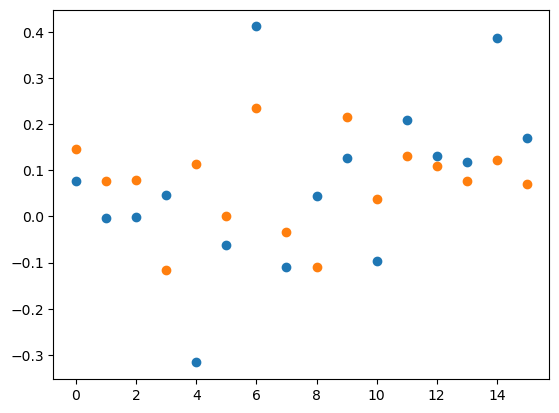

In [214]:
i = 1  # neuron to analyze


plt.scatter(np.arange(context_dim), embed_matrix[i])

i = 2  # neuron to analyze


plt.scatter(np.arange(context_dim), embed_matrix[i])

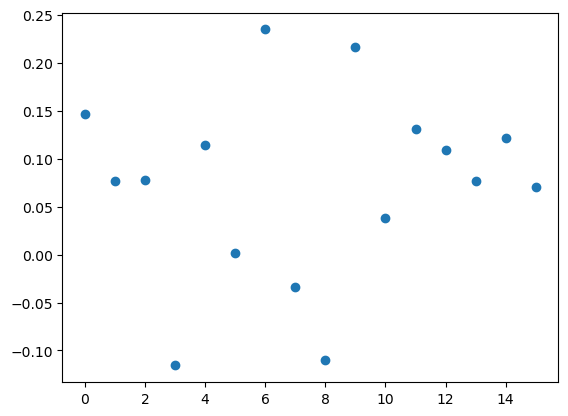

In [215]:
spike_id = 129
plt.scatter(np.arange(context_dim), embed_matrix[i])

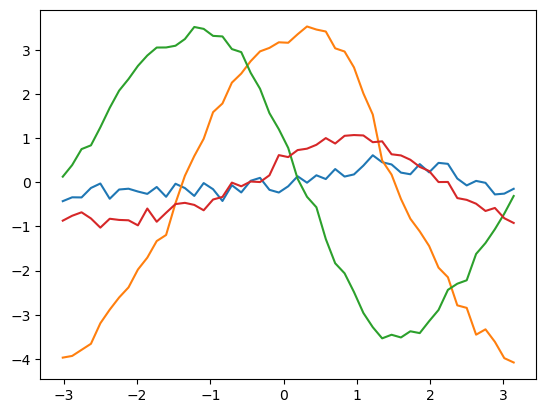

In [216]:
n_bins = 50
t_feature = t
feature = head_dir

context_binned, bins = analysis.bin_context_by_feature(
    feature, t_feature, bins=np.linspace(-np.pi, np.pi, n_bins), pca=True
)

c_feature_mean = np.array([np.mean(cb, axis=0) for cb in context_binned])

plt.plot(bins[1:], np.array(c_feature_mean)[:, :4])

# fig, ax = plt.subplots(nrows=9, sharex=True, figsize=(5, 12))
# for dat, loc in zip(context_binned, bins):
#     for i, a in enumerate(ax):
#         color = "cornflowerblue"
#         a.scatter(loc, np.median(dat[:, i]), c=color)

In [217]:
# rates_binned, bins = analysis.bin_context_by_feature(
#     feature, t_feature, bins=np.linspace(-np.pi, np.pi, n_bins),
#     alt_data=(t_spikes[::], rates[::, spike_id][:,None])
# )

# rates_feature_mean = np.array([np.mean(rb, axis=0) for rb in rates_binned])

# mua = rates.mean(axis=1)
# mua_binned, bins = analysis.bin_context_by_feature(
#     feature, t_feature, bins=np.linspace(-np.pi, np.pi, n_bins),
#     alt_data=(t_spikes[::], mua[:, None])
# )
# mua_feature_mean = np.array([np.mean(mb, axis=0) for mb in mua_binned])


mua = rates.mean(axis=1)
rel_rate = rates[:, spike_id] / mua
rel_rate_binned, bins = analysis.bin_context_by_feature(
    feature,
    t_feature,
    bins=np.linspace(-np.pi, np.pi, n_bins),
    alt_data=(t_spikes[::], rel_rate[:, None]),
)
rel_rate_feature_mean = np.array([np.nanmean(rb, axis=0) for rb in rel_rate_binned])

/tmp/ipykernel_3427287/1057777924.py:17: RuntimeWarning: invalid value encountered in divide
  rel_rate = rates[:, spike_id] / mua


array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 1.10535634,
        0.12662834],
       [0.        , 0.        , 0.        , ..., 0.        , 0.91284401,
        0.09357724],
       [0.        , 0.        , 0.        , ..., 0.        , 0.74461053,
        0.06830428]])

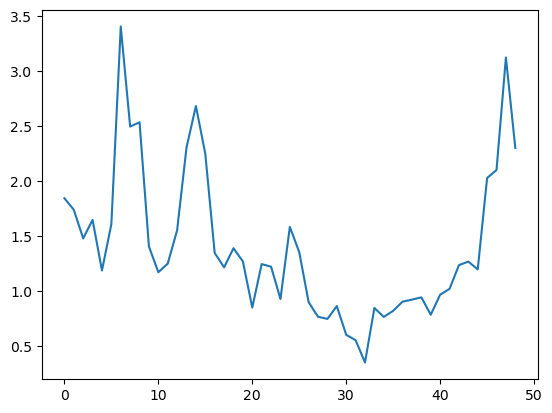

In [218]:
# plt.plot(rates_feature_mean)
# plt.plot(mua_feature_mean, c="k", lw=2)
plt.plot(rel_rate_feature_mean)
rates

In [219]:
plt.plot(rates_feature_mean)
plt.plot(mua_feature_mean, c="k", lw=2)
rates

NameError: name 'rates_feature_mean' is not defined

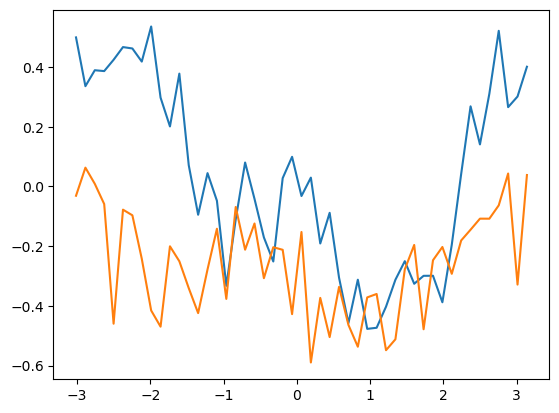

In [ ]:
c_feature_mean.shape, embed_matrix[spike_id].shape

predicted_field = c_feature_mean @ embed_matrix[spike_id]

empirical_field = rates_feature_mean
empirical_field = np.log(empirical_field / mua_feature_mean)
# empirical_field = np.log(rel_rate_feature_mean)

plt.plot(bins[1:], predicted_field)
plt.plot(bins[1:], empirical_field)

# Sensitivity/Specificity Analysis

In [ ]:
def discrete_entropy(dist):
    """Calculate the discrete entropy of a probability distribution."""
    dist = np.ravel(dist)
    return -np.sum(dist * np.log2(dist + 1e-10))


def mutual_information(p_x, p_y, p_xy):
    """Calculate the mutual information between two random variables."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return discrete_entropy(p_x) + discrete_entropy(p_y) - discrete_entropy(p_xy)


def _sensitivity(p_x, p_y, p_xy):
    """Calculate the sensitivity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_x)


def _specificity(p_x, p_y, p_xy):
    """Calculate the specificity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_y)


def invariance(p_x, p_y, p_n, p_xyn):
    """Calculate the invariance of y with respect to x."""
    return _specificity(p_x, p_y, p_xyn) - _specificity(p_x, p_n, p_xyn)


def analyze_representation(
    analysis,
    t_feature,
    feature,
    pc_set=None,
    c_bins=100,
    feature_bins=100,
    valid_intervals=None,
):
    t_data = analysis.t
    c_data = analysis.c_pca

    ind_feature = np.digitize(t_data, t_feature)
    aligned_feature = feature[ind_feature]
    if aligned_feature.ndim == 1:
        aligned_feature = aligned_feature[:, None]
    feature_bins = [
        np.linspace(
            np.min(aligned_feature[:, i]), np.max(aligned_feature[:, i]), feature_bins
        )
        for i in range(aligned_feature.shape[1])
    ]

    if isinstance(pc_set, int):
        pc_set = (pc_set,)
    ind_valid = (
        interval_list_contains_ind(valid_intervals, t_data)
        if valid_intervals is not None
        else np.ones(t_data.shape, dtype=bool)
    )
    aligned_feature = aligned_feature[ind_valid]
    c_data = c_data[ind_valid]
    c_bins = [
        np.linspace(np.min(c_data[:, i]), np.max(c_data[:, i]), c_bins) for i in pc_set
    ]

    full_data = np.concatenate([c_data[:, pc_set], aligned_feature], axis=1)
    p_joint = np.histogramdd(full_data, bins=c_bins + feature_bins)[0]
    p_joint = p_joint / np.sum(p_joint)

    # Calculate the marginal distributions
    p_context = np.sum(p_joint, axis=tuple(range(len(pc_set))))
    p_feature = np.sum(p_joint, axis=tuple(range(len(pc_set), len(p_joint.shape))))

    specificity = _specificity(p_feature, p_context, p_joint)
    sensitivity = _sensitivity(p_feature, p_context, p_joint)
    return specificity, sensitivity, p_joint

In [ ]:
t_feature = t.copy()
# feature_list = [head_dir, thetaphas]
feature_list = []
# feature = head_dir.copy()


# # feature = thetaphase.copy()
# feature = np.column_stack([x, y])
# # feature = y

feature_list.append(head_dir)
feature_list.append(thetaphase)
feature_list.append(np.column_stack([x, y]))

feature_names = ["head_dir", "thetaphase", "xy position"]

groups = [i for i in range(analysis.context_dim)]
groups = [i for i in range(8)]
groups.append((0, 3))
groups.append((1, 2))
groups.append((4, 5, 6, 7))
# groups.append((8,9,10,11))
# groups.append((12,13,14,15))

results = []
for feature in tqdm(feature_list):
    sensitivity = []
    specificity = []

    for i in groups:
        # print(f"Analyzing representation for PC set {i}")
        spec, sens, _ = analyze_representation(
            analysis, t_feature, feature, pc_set=i, c_bins=50, feature_bins=50
        )
        specificity.append(spec)
        sensitivity.append(sens)

    sensitivity = np.array(sensitivity)
    specificity = np.array(specificity)
    results.append((specificity, sensitivity))

100%|██████████| 3/3 [06:16<00:00, 125.42s/it]


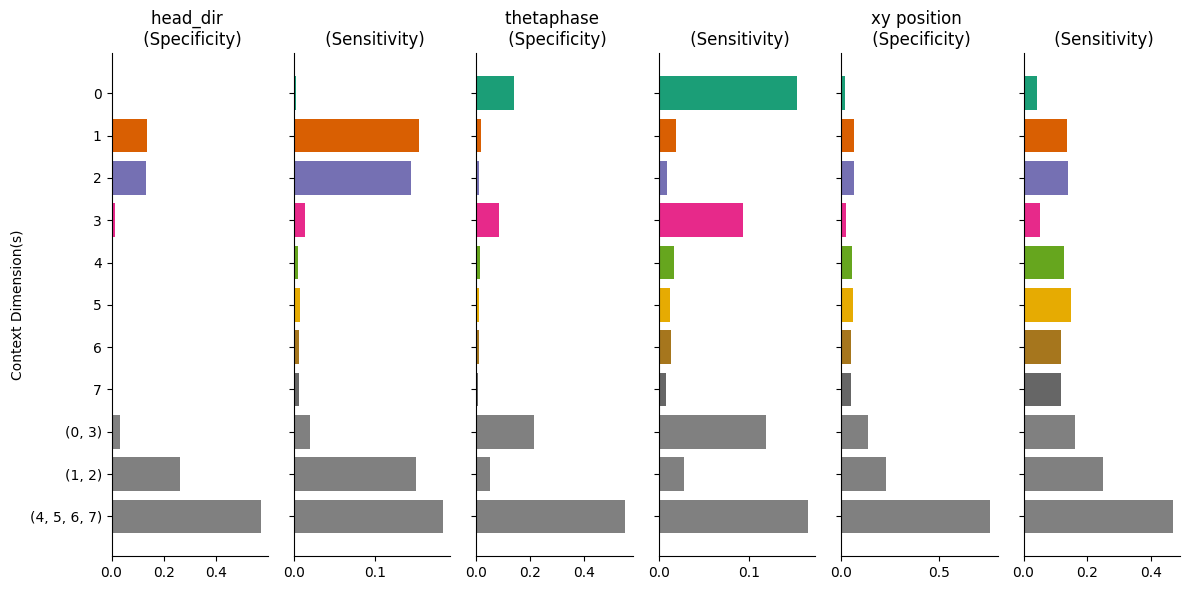

In [ ]:
# xx_labels = np.arange(len(specificity))
# xx = max(xx_labels) - xx_labels

xx = np.arange(len(groups))
xx = xx.max() - xx
xx_labels = groups

ind_single = [i for i in range(len(groups)) if isinstance(groups[i], int)]
ind_grouped = [i for i in range(len(groups)) if isinstance(groups[i], tuple)]
colors = ["blue", "red"]

fig, ax = plt.subplots(ncols=2 * len(results), sharey=True, figsize=(12, 6))


for i, (specificity, sensitivity) in enumerate(results):
    # for ind_set, color in zip([ind_single, ind_grouped], colors):
    #     ax[0 + 2*i].barh(xx[ind_set], specificity[ind_set], label='Specificity')
    #     ax[1 + 2*i].barh(xx[ind_set], sensitivity[ind_set], label='Sensitivity')
    for j in range(len(xx)):
        label = xx_labels[j]
        if isinstance(label, tuple):
            color = "grey"
        else:
            color = plt.cm.Dark2(label / 8)
        ax[2 * i].barh(xx[j], specificity[j], color=color)
        ax[1 + 2 * i].barh(xx[j], sensitivity[j], color=color)

    ax[2 * i].set_title(f"{feature_names[i]} \n (Specificity)")
    ax[1 + 2 * i].set_title(f"\n (Sensitivity)")

ax[0].set_yticks(xx, xx_labels)
ax[0].set_ylabel("Context Dimension(s)")


for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [ ]:
def discrete_entropy(dist):
    """Calculate the discrete entropy of a probability distribution."""
    dist = np.ravel(dist)
    return -np.sum(dist * np.log2(dist + 1e-10))


def mutual_information(p_x, p_y, p_xy):
    """Calculate the mutual information between two random variables."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return discrete_entropy(p_x) + discrete_entropy(p_y) - discrete_entropy(p_xy)


def sensitivity(p_x, p_y, p_xy):
    """Calculate the sensitivity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_x)


def specificity(p_x, p_y, p_xy):
    """Calculate the specificity of y with respect to x."""
    p_x = np.ravel(p_x)
    p_y = np.ravel(p_y)
    p_xy = np.ravel(p_xy)
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_y)


# def dice_coefficient(p_x, p_y):
#     """Calculate the Dice coefficient between two sets."""
#     p_x = np.ravel(p_x)
#     p_y = np.ravel(p_y)
#     return 2 * np.sum(p_x * p_y) / (np.sum(p_x) + np.sum(p_y))

# dice_coefficient(p_feature, p_context)


sensitivity(p_feature, p_context, p_joint), specificity(p_feature, p_context, p_joint)

(0.03660699120214733, 0.016317058521834973)

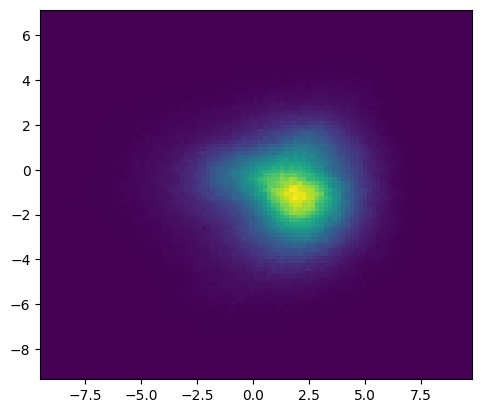

In [224]:
p_context = np.sum(p_joint, axis=-1)
p_context = p_context / np.sum(p_context)

plt.imshow(p_context, extent=[c_bins[0][0], c_bins[0][-1], c_bins[1][0], c_bins[1][-1]])

# plt.imshow(p_context.mean(axis=2))
# plt.colorbar()

In [ ]:
from src.c3po.analysis.analysis import interval_list_contains_ind

t_feature = t.copy()
feature = head_dir.copy()
# feature_bins = np.linspace(features.min(), features.max(), 10)


c_binned, feature_bins = analysis.bin_context_by_feature(
    feature, t_feature, pca=True, valid_intervals=valid_intervals, bins=100
)
c_all = np.concatenate(c_binned)

p_feature = np.histogram(feature, bins=feature_bins)[0]
p_feature = p_feature / np.sum(p_feature)

In [ ]:
i = 1
c_bins = np.linspace(np.min(c_all[:, i]), np.max(c_all[:, i]), 100)
p_context = np.histogram(c_all[:, i], bins=c_bins)[0]
p_context = p_context / np.sum(p_context)

p_feature_context = np.zeros((len(p_feature), len(p_context)))
for j, c in enumerate(c_binned):
    p_feature_context[j] = np.histogram(c[:, i], bins=c_bins)[0]
p_feature_context = p_feature_context / np.sum(p_feature_context)

In [ ]:
pc_set = (1, 2)


# c_bins = [np.linspace(np.min(c_all[:, i]), np.max(c_all[:, i]), 100) for i in pc_set]
p_context, c_bins = np.histogramdd(c_all[:, pc_set], bins=10)[0]
p_context = p_context / np.sum(p_context)

# p_feature_context = np.zeros((len(p_feature), len(p_context)))
# for j, c in enumerate(c_binned):
#     p_feature_context[j] = np.histogram(c[:,i], bins=c_bins)[0]
# p_feature_context = p_feature_context / np.sum(p_feature_context)

ValueError: too many values to unpack (expected 2)

In [149]:
r = np.histogramdd(c_all[:, pc_set], bins=(10, 10))[0]

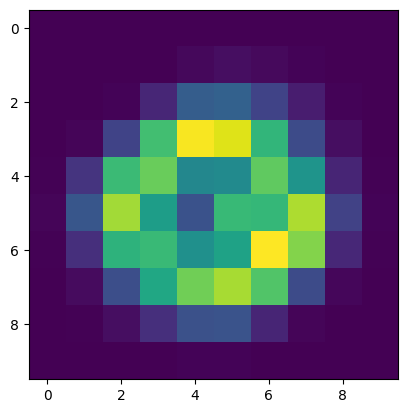

In [150]:
plt.imshow(r)

In [ ]:
def discrete_entropy(dist):
    """Calculate the discrete entropy of a probability distribution."""
    return -np.sum(dist * np.log2(dist + 1e-10))


def mutual_information(p_x, p_y, p_xy):
    """Calculate the mutual information between two random variables."""
    return discrete_entropy(p_x) + discrete_entropy(p_y) - discrete_entropy(p_xy)


def sensitivity(p_x, p_y, p_xy):
    """Calculate the sensitivity of y with respect to x."""
    return mutual_information(p_x, p_y, p_xy) / discrete_entropy(p_x)


sensitivity(p_feature, p_context, p_feature_context)
sensitivity(p_context, p_feature, p_feature_context)

0.17545007178565925

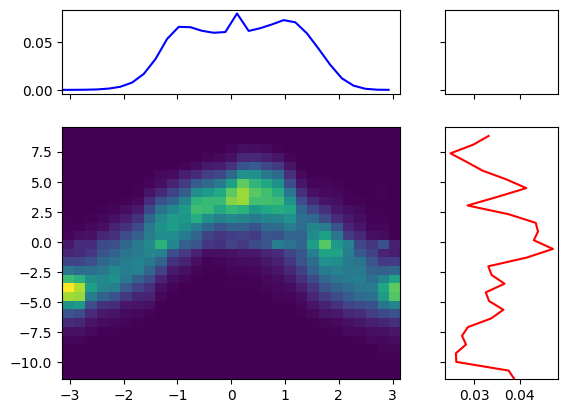

In [ ]:
# fig = plt.figure()
# gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], height_ratios=[1, 3],)
# ax_joint = fig.add_subplot(gs[1, 0])
# ax_marg_x = fig.add_subplot(gs[0, 0])
# ax_marg_y = fig.add_subplot(gs[1, 1])

fig, ax = plt.subplots(
    2, 2, width_ratios=[3, 1], height_ratios=[1, 3], sharex="col", sharey="row"
)
ax_joint = ax[1, 0]
ax_feature = ax[0, 0]
ax_context = ax[1, 1]


ax_joint.imshow(
    p_feature_context.T,
    aspect="auto",
    origin="lower",
    extent=[feature_bins[0], feature_bins[-1], c_bins[0], c_bins[-1]],
)

ax_feature.plot(feature_bins[:-1], np.sum(p_feature_context, axis=0), color="blue")
ax_context.plot(np.sum(p_feature_context, axis=1), c_bins[:-1], color="red")